In [1]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import dataclass
from typing import Tuple, List, Dict, Any

from scipy.integrate import solve_ivp

## 1. Definition of the Three-Tank System Parameters

In this notebook, we generate synthetic dynamic data from a three-tank system (TTS). The system consists of three interconnected liquid tanks with cross-sectional areas $A_1$, $A_2$, and $A_3$. Liquid enters tanks 1 and 3 through manipulated inlet flow rates $q_1(t)$ and $q_3(t)$, respectively. Liquid flows from tank 1 to tank 2, from tank 2 to tank 3, and finally exits from tank 3 through an outlet.

The state variables of the system are the liquid heights:

$$
\mathbf{x}(t) =
\begin{bmatrix}
h_1(t) \\
h_2(t) \\
h_3(t)
\end{bmatrix}
$$

where $h_1$, $h_2$, and $h_3$ denote the liquid levels in tanks 1, 2, and 3, respectively.

The function `orifice_flow` defines the gravity-driven flow through an orifice. The flow is modeled using a square-root dependence on the hydraulic head difference:

$$
q = k \sqrt{2g} \sqrt{\max(\Delta h, 0)}
$$

where $k$ is the flow coefficient, $g$ is gravitational acceleration, and $\Delta h$ is the available liquid head. The `max` operation ensures that the square root is evaluated only for non-negative head differences.

In [2]:
# Base Model parameters
@dataclass
class TTSParams:
    g: float = 9.81
    A1: float = 0.015
    A2: float = 0.015
    A3: float = 0.015
    k12: float = 6.0e-5
    k23: float = 6.0e-5
    k2:  float = 7.0e-5  # outlet from tank 3

def orifice_flow(k: float, head: float, g: float) -> float:
    return k * np.sqrt(2.0 * g) * np.sqrt(max(head, 0.0))

## 2. Time-Varying Inputs and Fault Event Representation

The inlet flow rates $q_1(t)$ and $q_3(t)$ are modeled as piecewise-constant input signals. This is useful for representing step changes in operating conditions, such as changes in inlet valve positions or pump flow rates.

The function `make_piecewise_constant_inputs` takes a time grid and corresponding input values. For any time $t$, we get inlet flow rates:

$$
u(t) =
\begin{bmatrix}
q_1(t) \\
q_3(t)
\end{bmatrix}
$$

This setup allows the process to be simulated under multiple operating regimes over a single simulation horizon.

Fault events are represented using the `FaultEvent` dataclass. Each event contains:

- `start`: the start time of the fault;
- `end`: the end time of the fault;
- `ftype`: the type of fault;
- `params`: fault-specific parameters;
- `event_id`: a unique event identifier.

In [3]:
# Inputs (piecewise constant)
def make_piecewise_constant_inputs(t_grid: np.ndarray, q1_vals: np.ndarray, q3_vals: np.ndarray):
    assert len(q1_vals) == len(t_grid) - 1
    assert len(q3_vals) == len(t_grid) - 1

    def u_of_t(t: float) -> Tuple[float, float]:
        idx = np.searchsorted(t_grid, t, side="right") - 1
        idx = int(np.clip(idx, 0, len(q1_vals) - 1))
        return float(q1_vals[idx]), float(q3_vals[idx])

    return u_of_t

# Fault events 
@dataclass
class FaultEvent:
    start: float
    end: float
    ftype: str
    params: Dict[str, Any]
    event_id: int

def active_events(t: float, events: List[FaultEvent]) -> List[FaultEvent]:
    return [e for e in events if (t >= e.start and t < e.end)]

## 3. Dynamic Model with Process and Actuator Faults

The function `TTS_rhs_transient` computes the time derivatives of the liquid levels:

$$
\frac{d\mathbf{x}}{dt}
=
\begin{bmatrix}
\frac{dh_1}{dt} \\
\frac{dh_2}{dt} \\
\frac{dh_3}{dt}
\end{bmatrix}
$$

At each time point, the model first retrieves the nominal inlet flow rates $q_1(t)$ and $q_3(t)$. It then checks whether any actuator or process faults are active and modifies the process accordingly.

The nominal material balances are:

$$
\frac{dh_1}{dt} = \frac{q_1 - q_{12}}{A_1}
$$

$$
\frac{dh_2}{dt} = \frac{q_{12} - q_{23}}{A_2}
$$

$$
\frac{dh_3}{dt} = \frac{q_3 + q_{23} - q_2}{A_3}
$$

where $q_{12}$ is the flow from tank 1 to tank 2, $q_{23}$ is the flow from tank 2 to tank 3, and $q_2$ is the outlet flow from tank 3.

The implemented fault types include actuator faults and process faults. Actuator faults directly affect the inlet flow rates, while process faults alter the physical behavior of the system.

For example:

- `act_q1_loss`: reduces the commanded inlet flow \(q_1(t)\),
- `act_q3_stuck`: freezes \(q_3(t)\) at a fixed value,
- `proc_k23_restrict`: reduces the flow coefficient between tanks 2 and 3,
- `proc_k12_restrict`: reduces the flow coefficient between tanks 1 and 2,
- `proc_k2_restrict`: reduces the tank 3 outlet coefficient,
- `proc_leak2`: introduces an additional leak from tank 2,
- `proc_leak3`: introduces an additional leak from tank 3.

Thus, the simulated trajectory contains both nominal operating changes and transient abnormal events.

In [4]:
# Transient process/actuator faults
def TTS_rhs_transient(t: float, x: np.ndarray, p: TTSParams, u_of_t, events: List[FaultEvent]) -> np.ndarray:
    h1, h2, h3 = x
    q1_cmd, q3_cmd = u_of_t(t)

    # nominal
    q1_act, q3_act = q1_cmd, q3_cmd
    k12, k23, k2 = p.k12, p.k23, p.k2
    kL1 = kL2 = kL3 = 0.0

    # apply all events 
    for e in active_events(t, events):
        if e.ftype == "act_q1_loss":
            gamma = float(e.params.get("gamma", 0.3))
            q1_act = (1.0 - gamma) * q1_cmd

        elif e.ftype == "act_q3_stuck":
            # hold q3 at its value at start of window
            q3_hold = float(e.params["q3_hold"])
            q3_act = q3_hold

        elif e.ftype == "proc_k23_restrict":
            beta = float(e.params.get("beta", 0.5))
            k23 = beta * p.k23

        elif e.ftype == "proc_k12_restrict":
            beta = float(e.params.get("beta", 0.5))
            k12 = beta * p.k12

        elif e.ftype == "proc_k2_restrict":
            beta = float(e.params.get("beta", 0.5))
            k2 = beta * p.k2

        elif e.ftype == "proc_leak2":
            kL2 = float(e.params.get("kL2", 4e-5))

        elif e.ftype == "proc_leak3":
            kL3 = float(e.params.get("kL3", 4e-5))

    # flows
    q12 = orifice_flow(k12, h1 - h2, p.g)
    q23 = orifice_flow(k23, h2 - h3, p.g)
    q2  = orifice_flow(k2,  h3,       p.g)

    # leaks
    qL2 = orifice_flow(kL2, h2, p.g) if kL2 > 0 else 0.0
    qL3 = orifice_flow(kL3, h3, p.g) if kL3 > 0 else 0.0

    dh1 = (q1_act - q12) / p.A1
    dh2 = (q12 - q23 - qL2) / p.A2
    dh3 = (q3_act + q23 - q2 - qL3) / p.A3

    return np.array([dh1, dh2, dh3], dtype=float)

## 4. Measurement Layer with Sensor Faults

After generating the true process states, a measurement layer is applied to mimic realistic sensor readings. The function `apply_sensor_faults` first adds Gaussian measurement noise to the true liquid level:

$$
h_i^{\mathrm{meas}}(t) = h_i^{\mathrm{true}}(t) + \epsilon_i(t)
$$

where

$$
\epsilon_i(t) \sim \mathcal{N}(0, \sigma_i^2)
$$

and $\sigma_i$ is the measurement noise standard deviation for sensor $i$.

In addition to random noise, transient sensor faults are applied over selected time intervals.

The implemented sensor faults include:

- `sens_bias`: adds a constant offset to the measured signal,
- `sens_drift`: introduces a time-dependent bias that grows linearly during the fault window,
- `sens_stuck`: freezes the sensor reading at the value observed at the beginning of the fault,
- `sens_noise_burst`: temporarily increases the measurement noise level,
- `sens_dropout`: replaces measurements with either missing values (`NaN`) or a held constant value.

These sensor faults affect only the measured variables and do not alter the true process states.

In [5]:
# Measurement layer with transient sensor faults
def apply_sensor_faults(
    t: np.ndarray,
    h_true: np.ndarray,
    events: List[FaultEvent],
    noise_std: float,
    rng: np.random.Generator,
    channel_name: str
) -> np.ndarray:
    """
    h_true shape: (T,)
    Applies noise + any active sensor faults (bias, drift, stuck, noise burst, dropout)
    """
    h_meas = h_true + rng.normal(0, noise_std, size=h_true.shape)

    for e in events:
        if e.ftype.startswith("sens_") and e.params.get("channel") == channel_name:
            mask = (t >= e.start) & (t < e.end)

            if e.ftype == "sens_bias":
                b = float(e.params.get("bias", 0.01))
                h_meas[mask] += b

            elif e.ftype == "sens_drift":
                alpha = float(e.params.get("alpha", 2e-5))  # m/s
                h_meas[mask] += alpha * (t[mask] - e.start)

            elif e.ftype == "sens_stuck":
                # freeze at value at start
                idx0 = np.where(t >= e.start)[0][0]
                h_meas[mask] = h_meas[idx0]

            elif e.ftype == "sens_noise_burst":
                factor = float(e.params.get("factor", 8.0))
                h_meas[mask] = h_true[mask] + rng.normal(0, factor * noise_std, size=mask.sum())

            elif e.ftype == "sens_dropout":
                mode = str(e.params.get("mode", "nan"))  # "nan" or "hold"
                if mode == "nan":
                    h_meas[mask] = np.nan
                else:
                    idx0 = np.where(t >= e.start)[0][0]
                    h_meas[mask] = h_meas[idx0]

    return h_meas

## 5. Random Fault Schedule Generation

The function `generate_fault_schedule` creates a randomized sequence of transient fault events. The events are designed to be short in duration and separated by a minimum gap, so that the resulting dataset contains alternating periods of nominal and faulty operation.

Each generated fault has:

$$
\text{fault event} =
\{\text{event ID}, \text{start time}, \text{end time}, \text{fault type}, \text{fault parameters}\}
$$

The fault type is randomly selected from a predefined list containing actuator faults, process faults, and sensor faults. The corresponding fault parameters are also randomly sampled from specified ranges.

For example, if the selected fault type is `proc_k23_restrict`, the function samples a restriction factor $\beta$, and the effective flow coefficient becomes:

$$
k_{23}^{\mathrm{fault}} = \beta k_{23}
$$

Similarly, if the selected fault type is `sens_bias`, the affected measurement channel is randomly selected from $h_1$, $h_2$, or $h_3$, and a bias magnitude is sampled.

The generated schedule is later saved separately as a CSV file to provide traceability for the synthetic dataset.

In [6]:
# Fault schedule generator
def generate_fault_schedule(
    rng: np.random.Generator,
    t0: float,
    tf: float,
    n_events: int = 12,
    dur_range: Tuple[float, float] = (40.0, 120.0),
    min_gap: float = 80.0
) -> List[FaultEvent]:
    """
    Creates non-overlapping short fault events.
    """
    fault_types = [
        # actuator / process
        "act_q1_loss",
        "proc_k23_restrict",
        "proc_k2_restrict",
        "proc_leak2",
        # sensor
        "sens_bias",
        "sens_drift",
        "sens_stuck",
        "sens_noise_burst",
        "sens_dropout",
    ]

    events: List[FaultEvent] = []
    current_time = t0 + 200.0  

    for eid in range(n_events):
        current_time += rng.uniform(min_gap, min_gap + 120.0)
        if current_time >= tf - dur_range[1]:
            break

        dur = rng.uniform(*dur_range)
        start = current_time
        end = min(start + dur, tf)

        ftype = rng.choice(fault_types)

        # default params by type
        params: Dict[str, Any] = {}
        if ftype == "act_q1_loss":
            params = {"gamma": float(rng.uniform(0.2, 0.6))}
        elif ftype == "proc_k23_restrict":
            params = {"beta": float(rng.uniform(0.3, 0.7))}
        elif ftype == "proc_k2_restrict":
            params = {"beta": float(rng.uniform(0.3, 0.7))}
        elif ftype == "proc_leak2":
            params = {"kL2": float(rng.uniform(2e-5, 7e-5))}
        elif ftype == "sens_bias":
            ch = rng.choice(["h1", "h2", "h3"])
            params = {"channel": ch, "bias": float(rng.uniform(-0.015, 0.015))}
        elif ftype == "sens_drift":
            ch = rng.choice(["h1", "h2", "h3"])
            params = {"channel": ch, "alpha": float(rng.uniform(-5e-5, 5e-5))}
        elif ftype == "sens_stuck":
            ch = rng.choice(["h1", "h2", "h3"])
            params = {"channel": ch}
        elif ftype == "sens_noise_burst":
            ch = rng.choice(["h1", "h2", "h3"])
            params = {"channel": ch, "factor": float(rng.uniform(5.0, 12.0))}
        elif ftype == "sens_dropout":
            ch = rng.choice(["h1", "h2", "h3"])
            params = {"channel": ch, "mode": rng.choice(["nan", "hold"])}

        events.append(FaultEvent(start=start, end=end, ftype=str(ftype), params=params, event_id=eid))
        current_time = end

    return events

## 6. Main Simulation Function

The function `simulate_TTS_multifault` performs the complete synthetic data generation workflow.

The main steps are:

1. Create the simulation time grid.
2. Solve the dynamic three-tank ODE model.
3. Reconstruct the commanded input profiles over time.
4. Compute the true internal flow rates.
5. Apply measurement noise and sensor faults.
6. Generate fault labels.
7. Store all variables in a Pandas DataFrame.

The dynamic model is integrated using `solve_ivp` with the `RK45` method. The output contains both the true process states and the measured sensor signals.

In [7]:
# Main simulator 
def simulate_TTS_multifault(
    p: TTSParams,
    t_span: Tuple[float, float],
    dt: float,
    x0: np.ndarray,
    u_of_t,
    events: List[FaultEvent],
    meas_noise_std: Dict[str, float] = None,
    seed: int = 0
) -> pd.DataFrame:
    if meas_noise_std is None:
        meas_noise_std = {"h1": 5e-4, "h2": 5e-4, "h3": 5e-4}

    t_eval = np.arange(t_span[0], t_span[1] + 1e-12, dt)

    # Solve ODE
    sol = solve_ivp(
        fun=lambda t, x: TTS_rhs_transient(t, x, p, u_of_t, events),
        t_span=t_span,
        y0=x0.astype(float),
        t_eval=t_eval,
        method="RK45",
        rtol=1e-7,
        atol=1e-9,
    )
    if not sol.success:
        raise RuntimeError(sol.message)

    t = sol.t
    h1, h2, h3 = sol.y

    q1_cmd = np.zeros_like(t)
    q3_cmd = np.zeros_like(t)
    for i, ti in enumerate(t):
        q1_cmd[i], q3_cmd[i] = u_of_t(float(ti))

    # true flows 
    q12_true = np.zeros_like(t)
    q23_true = np.zeros_like(t)
    q2_true  = np.zeros_like(t)

    # compute ks at each time based on active process faults
    for i, ti in enumerate(t):
        k12, k23, k2 = p.k12, p.k23, p.k2
        for e in active_events(float(ti), events):
            if e.ftype == "proc_k12_restrict":
                k12 = float(e.params.get("beta", 0.5)) * p.k12
            elif e.ftype == "proc_k23_restrict":
                k23 = float(e.params.get("beta", 0.5)) * p.k23
            elif e.ftype == "proc_k2_restrict":
                k2  = float(e.params.get("beta", 0.5)) * p.k2

        q12_true[i] = orifice_flow(k12, h1[i] - h2[i], p.g)
        q23_true[i] = orifice_flow(k23, h2[i] - h3[i], p.g)
        q2_true[i]  = orifice_flow(k2,  h3[i],        p.g)

    # measurements with transient sensor faults
    rng = np.random.default_rng(seed)
    h1m = apply_sensor_faults(t, h1, events, meas_noise_std["h1"], rng, "h1")
    h2m = apply_sensor_faults(t, h2, events, meas_noise_std["h2"], rng, "h2")
    h3m = apply_sensor_faults(t, h3, events, meas_noise_std["h3"], rng, "h3")

    # labels 
    fault_active = np.zeros_like(t, dtype=int)
    fault_type = np.array(["normal"] * len(t), dtype=object)
    fault_id = -np.ones_like(t, dtype=int)

    for e in events:
        mask = (t >= e.start) & (t < e.end)
        fault_active[mask] = 1
        fault_type[mask] = e.ftype
        fault_id[mask] = e.event_id

    df = pd.DataFrame({
        "t": t,
        "q1_cmd": q1_cmd,
        "q3_cmd": q3_cmd,
        "h1_true": h1, "h2_true": h2, "h3_true": h3,
        "h1_meas": h1m, "h2_meas": h2m, "h3_meas": h3m,
        "q12_true": q12_true, "q23_true": q23_true, "q2_true": q2_true,
        "fault_active": fault_active,
        "fault_type": fault_type,
        "fault_id": fault_id
    })

    return df

The final dataset includes the following variables:

- `t`: simulation time,
- `q1_cmd`, `q3_cmd`: commanded inlet flow rates,
- `h1_true`, `h2_true`, `h3_true`: true liquid levels,
- `h1_meas`, `h2_meas`, `h3_meas`: noisy and potentially faulty measurements,
- `q12_true`, `q23_true`, `q2_true`: true internal and outlet flow rates,
- `fault_active`: binary indicator for whether a fault is active,
- `fault_type`: type of active fault,
- `fault_id`: unique identifier of the active fault event.

This structure makes the dataset suitable for process monitoring, fault detection, event identification, and comparison of data-driven monitoring methods.

## 7. Example Simulation Run

In this example, the three-tank system is simulated from $t = 0$ to $t = 4000$ with a sampling interval of $dt = 1$. The initial liquid levels are set to:

$$
\mathbf{x}_0 =
\begin{bmatrix}
0.12 \\
0.10 \\
0.08
\end{bmatrix}
$$

The inlet flow rates $q_1(t)$ and $q_3(t)$ are defined as piecewise-constant signals over five operating intervals. These input changes introduce nominal process transients even in the absence of faults.

In [8]:
# Example run
if __name__ == "__main__":
    p = TTSParams()

    # Time 
    t0, tf = 0.0, 4000.0
    dt = 1.0
    x0 = np.array([0.12, 0.10, 0.08])

    # Inputs q1(t), q3(t)
    t_grid = np.array([0, 800, 1600, 2400, 3200, 4000], dtype=float)
    q1_vals = np.array([2.2e-5, 2.6e-5, 2.1e-5, 2.7e-5, 2.3e-5])
    q3_vals = np.array([1.4e-5, 1.8e-5, 1.5e-5, 1.9e-5, 1.6e-5])
    u_of_t = make_piecewise_constant_inputs(t_grid, q1_vals, q3_vals)

    # Make short transient fault schedule
    rng = np.random.default_rng(42)
    events = generate_fault_schedule(
        rng=rng,
        t0=t0,
        tf=tf,
        n_events=14,
        dur_range=(35.0, 110.0),
        min_gap=90.0
    )

    # Simulate
    df = simulate_TTS_multifault(
        p=p,
        t_span=(t0, tf),
        dt=dt,
        x0=x0,
        u_of_t=u_of_t,
        events=events,
        seed=123
    )

    # Save
    df.to_csv("TTS_multifault_short_events.csv", index=False)

    # Also save the fault schedule for traceability
    sched = pd.DataFrame([{
        "event_id": e.event_id, "start": e.start, "end": e.end,
        "fault_type": e.ftype, **e.params
    } for e in events])
    sched.to_csv("TTS_fault_schedule.csv", index=False)

A random fault schedule is generated using a fixed random seed for reproducibility. The dataset is then simulated and saved to:

```text
TTS_multifault_short_events.csv

The corresponding fault schedule is saved separately to:

```text
TTS_fault_schedule.csv

In [9]:
print(df.head())
print("\nSaved: TTS_multifault_short_events.csv")
print("Saved: TTS_fault_schedule.csv")

     t    q1_cmd    q3_cmd   h1_true   h2_true   h3_true   h1_meas   h2_meas  \
0  0.0  0.000022  0.000014  0.120000  0.100000  0.080000  0.119505  0.100718   
1  1.0  0.000022  0.000014  0.118991  0.099900  0.077705  0.118807  0.100908   
2  2.0  0.000022  0.000014  0.118033  0.099630  0.075610  0.118677  0.098973   
3  3.0  0.000022  0.000014  0.117114  0.099226  0.073687  0.117211  0.099146   
4  4.0  0.000022  0.000014  0.116224  0.098715  0.071911  0.116684  0.098793   

    h3_meas  q12_true  q23_true   q2_true  fault_active fault_type  fault_id  
0  0.080067  0.000038  0.000038  0.000088             0     normal        -1  
1  0.077018  0.000037  0.000040  0.000086             0     normal        -1  
2  0.075740  0.000036  0.000041  0.000085             0     normal        -1  
3  0.072973  0.000036  0.000042  0.000084             0     normal        -1  
4  0.072570  0.000035  0.000044  0.000083             0     normal        -1  

Saved: TTS_multifault_short_events.csv
Saved

## 8. Visualization of Measured Liquid-Level Signals

Finally, the measured liquid-level trajectories are plotted as a function of time. The plotted signals correspond to the noisy sensor measurements:

$$
h_1^{\mathrm{meas}}(t), \quad
h_2^{\mathrm{meas}}(t), \quad
h_3^{\mathrm{meas}}(t)
$$

These signals include the effects of nominal process dynamics, input changes, measurement noise, and transient sensor faults. Since the measurement layer can include biases, drifts, stuck sensors, noise bursts, or dropouts, the measured trajectories may differ from the true simulated states during faulty intervals.

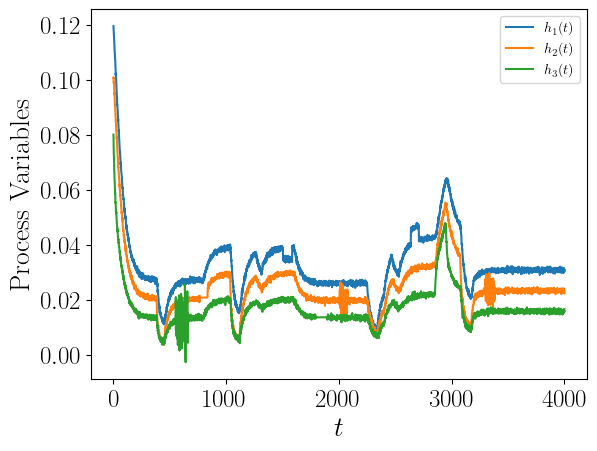

In [10]:
plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'axes.labelsize': 20,  
    'xtick.labelsize': 18, 
    'ytick.labelsize': 18, 
    'axes.titlesize': 24 
})

plt.figure()
plt.plot(df.h1_meas, label='$h_1 (t)$')
plt.plot(df.h2_meas, label='$h_2 (t)$')
plt.plot(df.h3_meas, label='$h_3 (t)$')
plt.xlabel('$t$')
plt.ylabel('Process Variables')
plt.legend()
plt.show()